In [1]:
import sys
sys.path.append("..") 
from Dataset.DatasetClass import QuarkGluonEvent, ResizeTensor
from Task1.calculate_std_mean import calculate_std_mean
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
import torch
from torchvision import transforms
import pickle
from train import train_autoencoder
from autoencoder import AutoEncoder2D
import torchsummary
from eval_autoencoder import test_autoencoder, compare_results

In [2]:
import random 
import numpy as np

def set_all_seeds(seed=42):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    g = torch.Generator()
    g.manual_seed(seed)  
    
    return g

In [3]:
DATA_PATH = "../Dataset/Data/raw/quark-gluon_data-set_n139306.hdf5"
g = set_all_seeds(42)
VAL_SPLIT = 0.20
TEST_SPLIT = 0.10
BATCH_SIZE = 16
NUM_WORKERS = 6
DEVICE = 'mps'
LOSS = nn.L1Loss()
OPTIMIZER = None

In [4]:
""" dataset = QuarkGluonEvent(DATA_PATH)
n = len(dataset)

train_size = int(n * (1 - (VAL_SPLIT + TEST_SPLIT)))
val_size   = int(n * VAL_SPLIT)
test_size  = n - train_size - val_size  

train_dataset, _, _ = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=g
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, generator=g, persistent_workers=True, prefetch_factor=4)  """

' dataset = QuarkGluonEvent(DATA_PATH)\nn = len(dataset)\n\ntrain_size = int(n * (1 - (VAL_SPLIT + TEST_SPLIT)))\nval_size   = int(n * VAL_SPLIT)\ntest_size  = n - train_size - val_size  \n\ntrain_dataset, _, _ = random_split(\n    dataset,\n    [train_size, val_size, test_size],\n    generator=g\n)\n\ntrain_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, generator=g, persistent_workers=True, prefetch_factor=4)  '

Calculation of mean and std for normalization

In [5]:
# mean, std = calculate_std_mean(train_loader)

In [6]:
with open('mean_std.pkl', 'rb') as f:
    mean_std= pickle.load(f)

In [7]:
mean, std = mean_std['mean'], mean_std['std']
print("Mean:", mean)
print("Std:", std)

Mean: tensor([7.9595e-05, 5.0834e-05, 3.0658e-05])
Std: tensor([0.0113, 0.0019, 0.0005])


In [8]:
transform = transforms.Compose([
    ResizeTensor((128,128)),
    transforms.Normalize(mean=mean, std=std),
])

In [9]:
# del train_loader, train_dataset

dataset = QuarkGluonEvent(DATA_PATH, transform=transform)

n = len(dataset)

train_size = int(n * (1 - (VAL_SPLIT + TEST_SPLIT)))
val_size   = int(n * VAL_SPLIT)
test_size  = n - train_size - val_size  

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=g
)

del dataset

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, generator=g)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, generator=g)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, generator=g)

In [10]:
input_shape = train_dataset.dataset.X_jets.shape[1:]  # (channels, height, width)
print(f"Input shape: {input_shape}")

model = AutoEncoder2D(input_shape=input_shape, latent_dim=128, base=32, layer_count=3)

torchsummary.summary(model, input_size=input_shape, device='cpu')

Input shape: torch.Size([3, 125, 125])
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 63, 63]             864
       BatchNorm2d-2           [-1, 32, 63, 63]              64
              ReLU-3           [-1, 32, 63, 63]               0
            Conv2d-4           [-1, 64, 32, 32]          18,432
       BatchNorm2d-5           [-1, 64, 32, 32]             128
              ReLU-6           [-1, 64, 32, 32]               0
            Conv2d-7          [-1, 128, 16, 16]          73,728
       BatchNorm2d-8          [-1, 128, 16, 16]             256
              ReLU-9          [-1, 128, 16, 16]               0
           Linear-10                  [-1, 128]       4,194,432
        Encoder2D-11                  [-1, 128]               0
           Linear-12                [-1, 32768]       4,227,072
  ConvTranspose2d-13           [-1, 64, 32, 32]         131,072


In [11]:
OPTIMIZER = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(OPTIMIZER, factor=0.5, patience=5)


train_autoencoder(model, train_loader, val_loader, DEVICE, LOSS, OPTIMIZER, mean, std, early_stopping_patience=5, EPOCHS=40, scheduler=scheduler, alpha=0.5)

Epoch 1/40 - Training:   0%|          | 0/6095 [00:00<?, ?it/s]

/Users/enesdemir/Desktop/genie_gsoc/Task1/train.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mean = torch.tensor(mean).view(1, -1, 1, 1).to(tensor.device)
/Users/enesdemir/Desktop/genie_gsoc/Task1/train.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  std = torch.tensor(std).view(1, -1, 1, 1).to(tensor.device)


Epoch 1/40 - Validation:   0%|          | 0/1742 [00:00<?, ?it/s]

Epoch 2/40 - Training:   0%|          | 0/6095 [00:00<?, ?it/s]

Epoch 2/40 - Validation:   0%|          | 0/1742 [00:00<?, ?it/s]

...

Epoch 21/40 - Training:   0%|          | 0/6095 [00:00<?, ?it/s]

Epoch 21/40 - Validation:   0%|          | 0/1742 [00:00<?, ?it/s]

Epoch 22/40 - Training:   0%|          | 0/6095 [00:00<?, ?it/s]

Epoch 22/40 - Validation:   0%|          | 0/1742 [00:00<?, ?it/s]

Early stopping triggered.
Training complete.
Best model saved at best_model.pth with epoch_17 complated - val_loss: 0.0585, train_loss: 0.0581, train_l2_loss: 0.5048, val_l2_loss: 0.5248, train_ssim: 0.9983, val_ssim: 0.9983, lr: 0.001000


In [9]:
import torch

model = AutoEncoder2D(input_shape=(3, 128, 128), latent_dim=128, base=32, layer_count=3)

model.to(DEVICE)

checkpoint = torch.load('best_model.pth', weights_only=True)

model.load_state_dict(checkpoint, strict=False)

print("Model loaded successfully with non-strict loading") 

Model loaded successfully with non-strict loading


In [12]:
test_loss, test_l2_loss, test_ssim_metric = test_autoencoder(model, test_loader, DEVICE, LOSS, mean, std, alpha=0.5)

/Users/enesdemir/Desktop/genie_gsoc/Task1/train.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mean = torch.tensor(mean).view(1, -1, 1, 1).to(tensor.device)
/Users/enesdemir/Desktop/genie_gsoc/Task1/train.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  std = torch.tensor(std).view(1, -1, 1, 1).to(tensor.device)


In [13]:
print(f"Test Loss: {test_loss:.4f}, Test L2 Loss: {test_l2_loss:.4f}, Test SSIM: {test_ssim_metric:.4f}")

Test Loss: 0.0584, Test L2 Loss: 2.7873, Test SSIM: 0.9983


/Users/enesdemir/Desktop/genie_gsoc/Task1/train.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mean = torch.tensor(mean).view(1, -1, 1, 1).to(tensor.device)
/Users/enesdemir/Desktop/genie_gsoc/Task1/train.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  std = torch.tensor(std).view(1, -1, 1, 1).to(tensor.device)


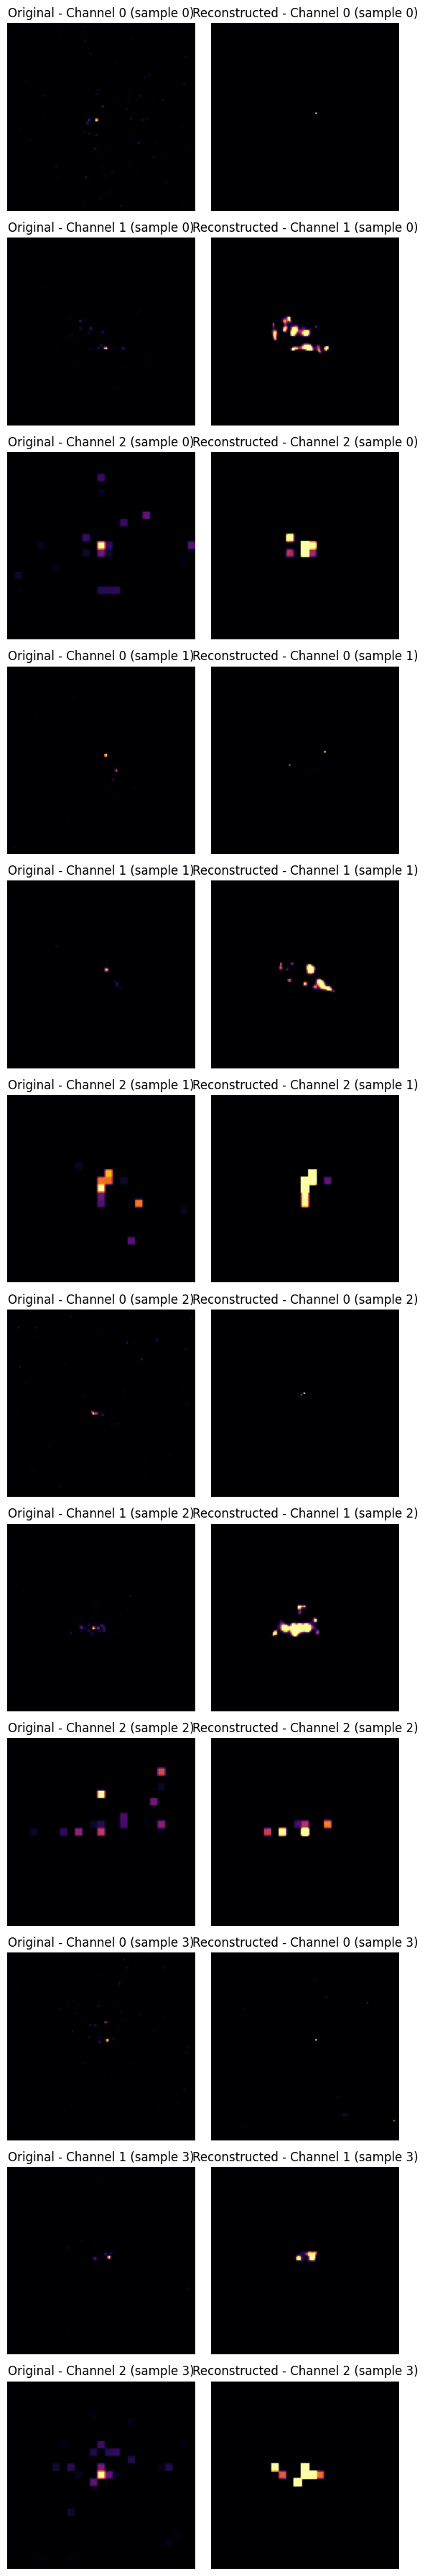

In [10]:
compare_results(model, DATA_PATH, mean, std, 4, transform=transform)